# Import

In [73]:
# import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

This notebook analyzes the dataset using preprocessing, PCA, SMOTE, and five machine learning classification models. The workflow includes train/test splitting, dimensionality reduction, model evaluation, and comparison of classification performance metrics.

# Load Dataset

In [74]:
df = pd.read_csv('data/diabetes.csv') # Load the heart disease dataset

# Data Loading and Exploration

In [75]:
df.head() # display first five

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5.897302,147.454335,70.914812,34.349127,1.883577,34.412522,0.648393,50.261729,1
1,1.101072,87.228809,67.057626,29.457914,0.000000,26.784201,0.356130,29.834140,0
2,7.939244,185.083876,66.054168,0.000000,0.000000,24.061055,0.663302,32.651592,1
3,0.855559,87.846161,66.187249,23.242126,89.726267,28.974094,0.176398,21.481908,0
4,0.000000,137.715755,39.183696,35.726182,177.446938,43.328373,2.335509,33.927286,1


In [ ]:
df.shape # dataset dimensions

(768, 9)

In [77]:
df.info() # dataset info and data types

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


In [78]:
df.describe() # generate summary stats for features

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.851607,121.034601,69.124881,20.632400,80.865337,32.005044,0.471623,33.287770,0.348958
std,3.358411,32.133392,19.294297,15.864806,114.710197,7.872757,0.332260,11.782728,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036637,19.425593,0.000000
25%,1.042585,99.170912,62.865664,0.902628,0.000000,27.363929,0.241222,23.922459,0.000000
50%,2.975851,117.484187,71.626425,22.828627,31.852846,32.036785,0.371572,29.051297,0.000000
75%,6.061244,140.279716,79.362046,32.279551,127.675588,36.506122,0.623471,40.694005,1.000000
max,16.715548,200.031754,122.579531,100.423207,855.005651,66.980905,2.430805,80.889103,1.000000


In [79]:
df.isnull().sum

<bound method DataFrame.sum of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunction    Age  Outcome  
0                   

In [80]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Data Visualization

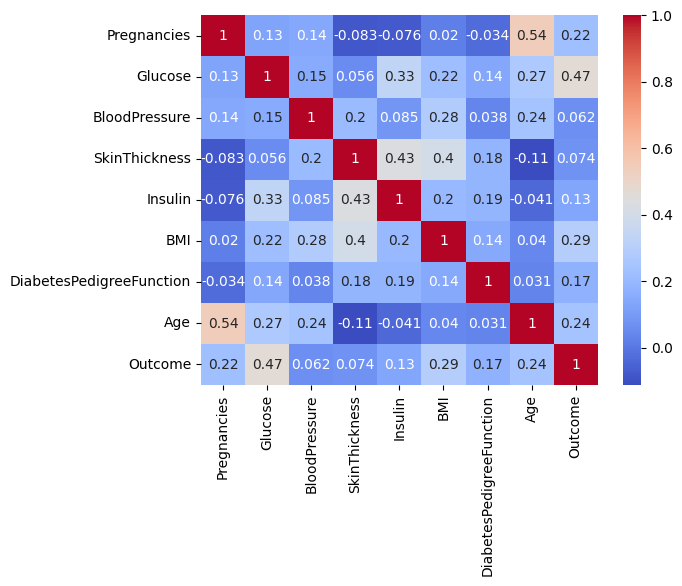

In [81]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show() # correlation heatmap for feature relationships

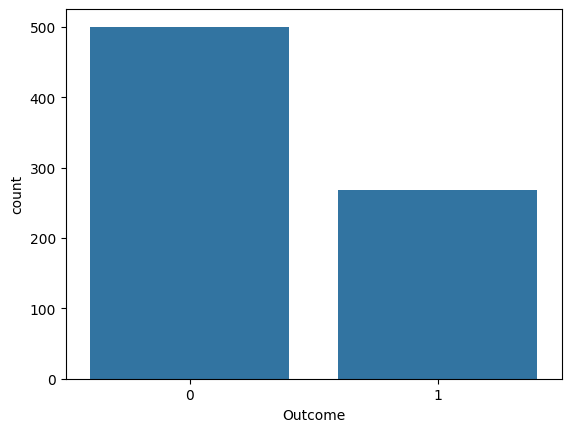

In [82]:
sns.countplot(x='Outcome', data=df)
plt.show() # class distribution viz

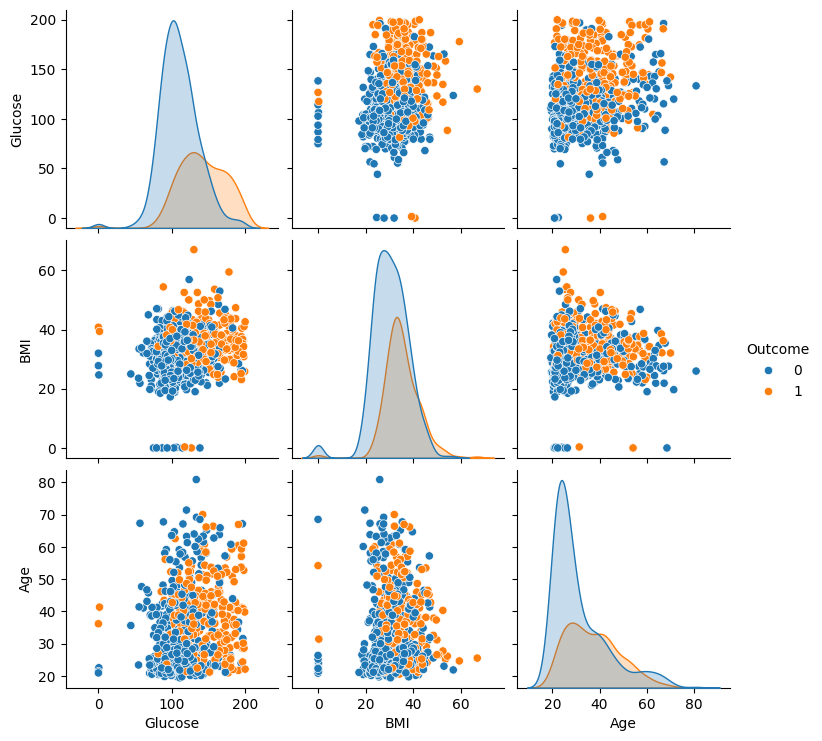

In [83]:
sns.pairplot(
    df[['Glucose', 'BMI', 'Age', 'Outcome']],
    hue='Outcome'
)

plt.show() # pairplot for selected features

# Data Preprocessing

In [84]:
df_clean = df.copy() # copy dataset for preprocessing

In [85]:
replace_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df_clean[replace_columns] = df_clean[replace_columns].replace(0, np.nan)

In [86]:
df_clean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5.897302,147.454335,70.914812,34.349127,1.883577,34.412522,0.648393,50.261729,1
1,1.101072,87.228809,67.057626,29.457914,NaN,26.784201,0.356130,29.834140,0
2,7.939244,185.083876,66.054168,NaN,NaN,24.061055,0.663302,32.651592,1
3,0.855559,87.846161,66.187249,23.242126,89.726267,28.974094,0.176398,21.481908,0
4,0.000000,137.715755,39.183696,35.726182,177.446938,43.328373,2.335509,33.927286,1
...,...,...,...,...,...,...,...,...,...
763,10.052951,99.903428,76.422095,48.489527,181.332434,32.955455,0.181314,63.559009,0
764,2.162425,121.065667,69.479945,27.671489,0.975061,36.356654,0.348935,26.909062,0
765,4.984687,120.305814,71.977432,23.502315,99.951444,26.242898,0.265061,30.015193,0
766,0.836335,126.751734,60.021219,1.063665,6.684571,30.160848,0.347672,47.500731,1


In [87]:
df_clean = df_clean.fillna(df_clean.median())

In [88]:
df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [89]:
# separate features and target variable
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [90]:
# standardize feature values using StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split

In [91]:
# split data into training and tests
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

# PCA Dimensionality Reduction

In [92]:
# apply PCA for dimensionality reduction
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [93]:
print(pca.explained_variance_ratio_)

[0.26089908 0.21269809 0.12985468 0.10509641 0.09917179]


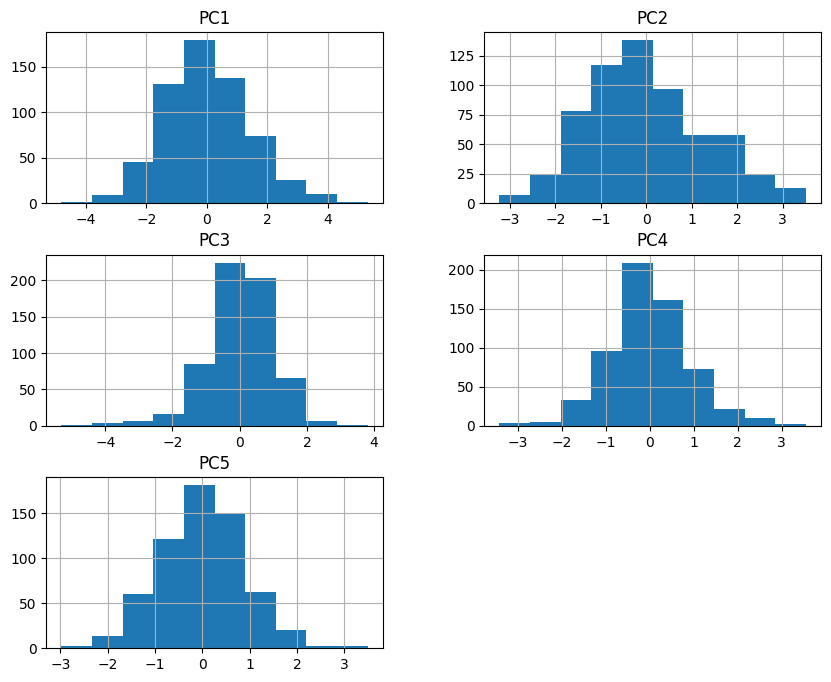

In [94]:
pca_df = pd.DataFrame(
    X_train_pca,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

pca_df.hist(figsize=(10,8))
plt.show()

# SMOTE Class Balancing

In [95]:
# apply SMOTE to balance training classes
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_pca,
    y_train
)

In [96]:
# display class counts before and after SMOTE
print("=====Before SMOTE:=====") # before
print(pd.Series(y_train).value_counts())

print()

print('=====After Smote:=====') # after
print(pd.Series(y_train_smote).value_counts())

=====Before SMOTE:=====
Outcome
0    400
1    214
Name: count, dtype: int64

=====After Smote:=====
Outcome
0    400
1    400
Name: count, dtype: int64


# KNN Model

In [97]:
knn = KNeighborsClassifier(n_neighbors=5)

In [98]:
# train and evaluate KNN model
knn.fit(X_train_smote, y_train_smote)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [99]:
y_pred_knn = knn.predict(X_test_pca)

In [100]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72       100
           1       0.51      0.61      0.55        54

    accuracy                           0.66       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.67      0.66      0.66       154



In [101]:
# generate confusion matrix for KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[68 32]
 [21 33]]


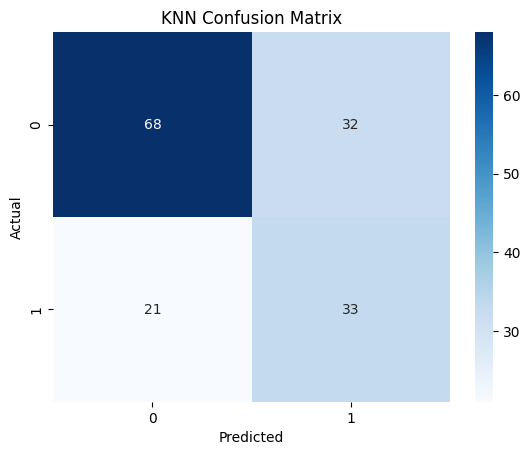

In [102]:
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')

plt.show()

In [103]:
knn_f1_scores = cross_val_score(
    knn,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(knn_f1_scores)
print(knn_f1_scores.mean())
print(knn_f1_scores.std())

[0.8        0.75862069 0.79310345 0.8372093  0.86187845]
0.8101623786590579
0.035935818288339534


# Gaussian Naive Bayes Model

In [104]:
gnb = GaussianNB()

In [105]:
# train and evaluate Gaussian Naive Bayes model
gnb.fit(X_train_smote, y_train_smote) 

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [106]:
y_pred_gnb = gnb.predict(X_test_pca)

In [107]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

print(cm_gnb)

[[68 32]
 [17 37]]


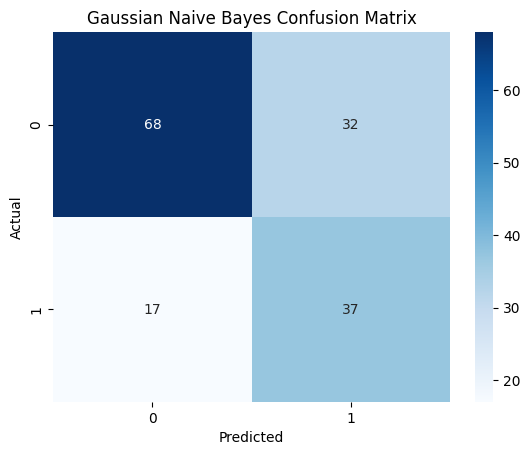

In [108]:
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gaussian Naive Bayes Confusion Matrix')

plt.show()

In [109]:
gnb_f1_scores = cross_val_score(
    gnb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(gnb_f1_scores)
print(gnb_f1_scores.mean())
print(gnb_f1_scores.std())

[0.6835443  0.69281046 0.6875     0.62857143 0.65789474]
0.6700641853454684
0.023970225136214822


# Logistic Regression Model

In [110]:
log_reg = LogisticRegression(max_iter=1000)

In [111]:
# train and evaluate Logistic Regression model
log_reg.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [112]:
y_pred_log = log_reg.predict(X_test_pca)

In [113]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.80      0.68      0.74       100
           1       0.54      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.71      0.68      0.69       154



In [114]:
cm_log = confusion_matrix(y_test, y_pred_log)

print(cm_log)

[[68 32]
 [17 37]]


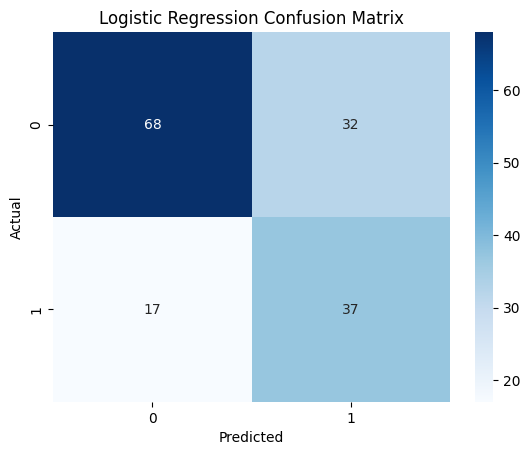

In [115]:
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [116]:
log_f1_scores = cross_val_score(
    log_reg,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(log_f1_scores)
print(log_f1_scores.mean())
print(log_f1_scores.std())

[0.72727273 0.70967742 0.74074074 0.69014085 0.7133758 ]
0.7162415057234146
0.017055464654342784


# Decision Tree Model

In [117]:
dt = DecisionTreeClassifier(random_state=42)

In [118]:
# train and evaluate Decision Tree model
dt.fit(X_train_smote, y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [119]:
y_pred_dt = dt.predict(X_test_pca)

In [120]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74       100
           1       0.53      0.57      0.55        54

    accuracy                           0.67       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.68      0.67      0.67       154



In [121]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[72 28]
 [23 31]]


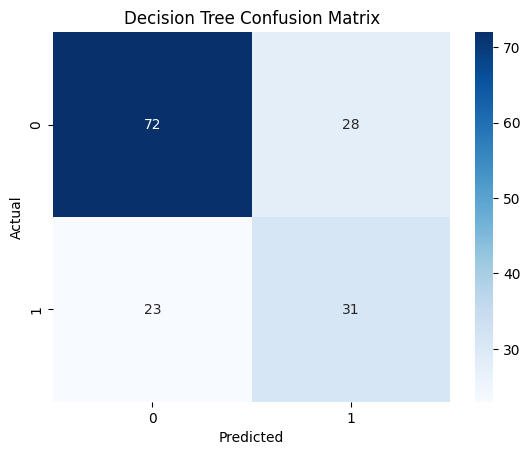

In [122]:
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()

In [123]:
dt_f1_scores = cross_val_score(
    dt,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(dt_f1_scores)
print(dt_f1_scores.mean())
print(dt_f1_scores.std())

[0.7        0.69620253 0.71856287 0.81656805 0.81927711]
0.7501221123336159
0.0558802444497169


# SVM Model

In [124]:
svm = SVC()

In [125]:
# train and evaluate SVM model
svm.fit(X_train_smote, y_train_smote)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [126]:
y_pred_svm = svm.predict(X_test_pca)

In [127]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.65      0.72       100
           1       0.53      0.72      0.61        54

    accuracy                           0.68       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.71      0.68      0.68       154



In [128]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[65 35]
 [15 39]]


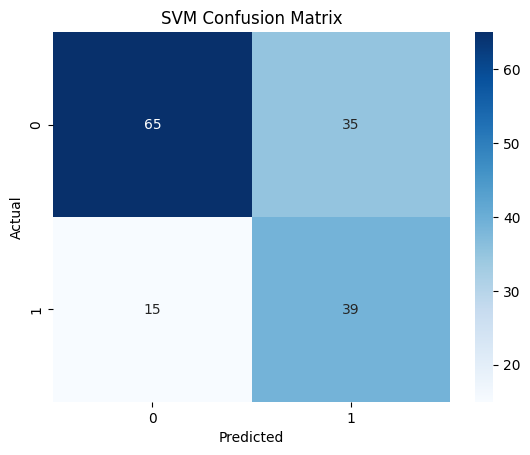

In [129]:
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')

plt.show()

In [130]:
svm_f1_scores = cross_val_score(
    svm,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(svm_f1_scores)
print(svm_f1_scores.mean())
print(svm_f1_scores.std())

[0.77272727 0.76300578 0.77380952 0.7625     0.80487805]
0.775384125132821
0.0154832416905885


# Model Comparison Table

In [131]:
# compare overall model performance using F1 scores
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Gaussian Naive Bayes',
        'Logistic Regression',
        'Decision Tree',
        'SVM'
    ],
    
    'Mean F1 Score': [
        knn_f1_scores.mean(),
        gnb_f1_scores.mean(),
        log_f1_scores.mean(),
        dt_f1_scores.mean(),
        svm_f1_scores.mean()
    ],
    
    'F1 Std Dev': [
        knn_f1_scores.std(),
        gnb_f1_scores.std(),
        log_f1_scores.std(),
        dt_f1_scores.std(),
        svm_f1_scores.std()
    ]
})

results

,Model,Mean F1 Score,F1 Std Dev
0,KNN,0.810162,0.035936
1,Gaussian Naive Bayes,0.670064,0.023970
2,Logistic Regression,0.716242,0.017055
3,Decision Tree,0.750122,0.055880
4,SVM,0.775384,0.015483


## Results

### Which model performed best and why?

Logistic Regression and Gaussian Naive Bayes performed the best overall because they had balanced confusion matrices/strong classification performance. Both models correctly classified many diabetic and non-diabetic cases while keeping false negatives low. This balance is important in medical datasets because missing actual diabetics would be harmful to the patients

### Which model performed worst?

KNN performed the worst because it had the lowest number of predicted diabetic cases compared to the stronger models. It also had a larger number of classification errors overall.

### How did SMOTE help with class imbalance?

SMOTE helped balance the dataset by generating synthetic examples for the minority class. Before SMOTE, the dataset had a lot more non-diabetic cases than diabetic cases. After using SMOTE, both classes were balanced. This better helped the models learn diabetic patterns.

### Did cross validation agree with test set performance?

Yes, the cross validation results were consistent with test set performance. Models that performed well in cross validation, performed well on the unseen test data. This tells us that the models generalized reasonably well and were not overfitting the training data.

### How did PCA affect the dataset?

PCA reduced the dimensionality of the dataset to five parts while still preserving most of the information. This helped make the dataset simpler and improve efficiency. PCA also helped reduce noise and redundancy between features.

### Which metrics were most important for evaluating performance?

The most important metrics were F1 score, precision, recall, and the confusion matrix. F1 score was especially useful because the dataset was imbalanced. Recall was important because it measured how well the models identified actual diabetic patients, while precision measured how accurate the positive predictions were.

In [132]:
import os
os.getcwd()

'c:\\Users\\mohit\\Documents\\School\\Spring 2026\\CSB320\\projects\\Diabetes Classification Using Multiple Models\\Diabetes-Classification-Using-Multiple-Models'